In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    ConfusionMatrixDisplay
)

In [8]:
matches = pd.read_csv('../data/processed/features_v2.csv')

matches.head()

,Season,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,...,HomeGoalsPerGame,AwayGoalsPerGame,HomeGoalsAgainstPerGame,AwayGoalsAgainstPerGame,HomeGDPerGame,AwayGDPerGame,PPGDiff,GDPerGameDiff,GoalsPerGameDiff,GoalsAgainstPerGameDiff
0,21-22,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,21-22,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,21-22,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,21-22,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,21-22,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
matches['GoalDiffLast5'] = matches['HomeGoalsLast5'] - matches['AwayGoalsLast5'] 
matches['PointsDiffLast5'] = matches['HomePointsLast5'] - matches['AwayPointsLast5'] 
matches['GoalAgainstDiffLast5'] = matches['AwayGoalsAgainstLast5'] - matches['HomeGoalsAgainstLast5'] 
matches['ShotDiffLast5'] = matches['HomeShotsForLast5'] - matches['AwayShotsForLast5'] 
matches['ShotOTDiffLast5'] = matches['HomeShotsOnTargetLast5'] - matches['AwayShotsOnTargetLast5']

C:\Users\harry\AppData\Local\Temp\ipykernel_28732\2143085457.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matches['GoalDiffLast5'] = matches['HomeGoalsLast5'] - matches['AwayGoalsLast5']
C:\Users\harry\AppData\Local\Temp\ipykernel_28732\2143085457.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matches['PointsDiffLast5'] = matches['HomePointsLast5'] - matches['AwayPointsLast5']
C:\Users\harry\AppData\Local\Temp\ipykernel_28732\2143085457.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

In [10]:
features = [
    'PPGDiff',
    'GoalAgainstDiffLast5',
    'ShotOTDiffLast5',
    'GDPerGameDiff',
    'GoalsAgainstPerGameDiff'
]

In [11]:
train = matches[matches['Season'] != '25-26']
test = matches[matches['Season'] == '25-26']

X_train = train[features]
y_train = train['FTR']

X_test = test[features]
y_test = test['FTR']

print(X_train.shape, X_test.shape)

(1520, 5) (380, 5)


In [12]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

In [13]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [14]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)

print(model.classes_)

['A' 'D' 'H']


In [15]:
accuracy = accuracy_score(y_test, preds)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.4684


In [16]:
ll = log_loss(y_test, probs)

print(f'Log loss: {ll:.4f}')

Log loss: 1.0479


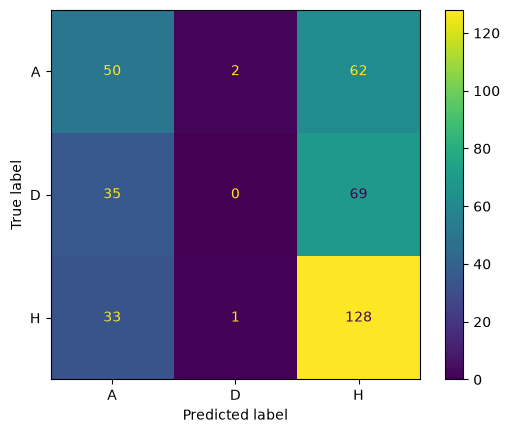

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.show()

In [18]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

PPGDiff                    0.279606
GDPerGameDiff              0.279565
GoalsAgainstPerGameDiff    0.221322
ShotOTDiffLast5            0.133138
GoalAgainstDiffLast5       0.086369
dtype: float64


In [19]:
results = test[['HomeTeam', 'AwayTeam', 'FTR']].copy()

results['Predicted'] = preds

results['AwayProb'] = probs[:, 0]
results['DrawProb'] = probs[:, 1]
results['HomeProb'] = probs[:, 2]

results['Correct'] = results['Predicted'] == results['FTR']

results.head(10)

,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb,Correct
1520,Liverpool,Bournemouth,H,H,0.313424,0.210910,0.475666,True
1521,Aston Villa,Newcastle,D,H,0.340572,0.215722,0.443707,False
1522,Brighton,Fulham,D,H,0.235737,0.173600,0.590663,False
1523,Sunderland,West Ham,H,H,0.353716,0.209040,0.437243,True
1524,Tottenham,Burnley,H,A,0.435849,0.199169,0.364982,False
1525,Wolves,Man City,A,H,0.371727,0.212783,0.415491,False
1526,Chelsea,Crystal Palace,D,H,0.319791,0.218250,0.461959,False
1527,Nott'm Forest,Brentford,H,H,0.341961,0.219627,0.438412,True
1528,Man United,Arsenal,A,H,0.311955,0.205286,0.482759,False
1529,Leeds,Everton,H,A,0.393121,0.216005,0.390874,False


In [20]:
results.sort_values('HomeProb', ascending=False).head(15)[[
    'HomeTeam', 'AwayTeam', 'FTR',
    'Predicted', 'HomeProb', 'Correct'
]]

,HomeTeam,AwayTeam,FTR,Predicted,HomeProb,Correct
1673,Arsenal,Wolves,H,H,0.854203,True
1705,Man United,Wolves,D,H,0.821183,False
1695,Liverpool,Wolves,H,H,0.784719,True
1683,Man City,West Ham,H,H,0.773557,True
1624,Chelsea,Wolves,H,H,0.766428,True
1646,Aston Villa,Wolves,H,H,0.750660,True
1887,Arsenal,Burnley,H,H,0.720695,True
1641,Man City,Leeds,H,H,0.718847,True
1743,Man City,Wolves,H,H,0.715974,True
1576,Tottenham,Wolves,D,H,0.715311,False


In [21]:
results['HomeProbBin'] = pd.cut(
    results['HomeProb'],
    bins=[0, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
)

calibration = results.groupby('HomeProbBin')['Correct'].agg(['mean', 'count'])

calibration

,mean,count
HomeProbBin,,
"(0.0, 0.4]",0.419847,131
"(0.4, 0.5]",0.434343,99
"(0.5, 0.6]",0.500000,86
"(0.6, 0.7]",0.528302,53
"(0.7, 0.8]",0.888889,9
"(0.8, 1.0]",0.500000,2


In [22]:
for threshold in [0.55, 0.60, 0.65, 0.70]:
    subset = results[results['HomeProb'] >= threshold]

    if len(subset) > 0:
        acc = subset['Correct'].mean()
        print(f'{threshold:.2f}  matches={len(subset):3d}  accuracy={acc:.3f}')

0.55  matches=104  accuracy=0.538
0.60  matches= 64  accuracy=0.578
0.65  matches= 28  accuracy=0.607
0.70  matches= 11  accuracy=0.818


In [23]:
matches.groupby('FTR')['PPGDiff'].mean()

FTR
A   -0.398921
D   -0.062422
H    0.256762
Name: PPGDiff, dtype: float64